# Analysis

- venn diagrams for facial, anogenital, body sniffing
- threshold >350 ms
- Make sure it's during the 10 min interaction
- subject initiated events for now


# Behavior plots
- avg event bout time
- make sure you get d0 vs d7 for these
- other stuff sequoia sent

In [472]:
from spike.spike_analysis.spike_collection import SpikeCollection
import pandas as pd, numpy as np, re
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

# Path to your local SpikeCollection JSON
json_path = r"C:\Users\thoma\Code\ResearchCode\rehouse\diff_fam_social_memory_ephys\thomas-social-memory\data\spike_collection.json"
sc = SpikeCollection.load_collection(json_path)


# Calculates mean firing rate per good neuron then per rec

In [473]:
1800/60

30.0

In [474]:
for rec in sc.recordings:
    print(rec.timestamps[-1]/rec.sampling_rate)
    

1801.38725
1802.44035
1802.2795
1801.05495
1802.24935
1801.1959
1800.9173
1801.17695
1800.3898


In [475]:
recording_rows = []
for rec in sc.recordings:
    units = [u for u, label in rec.labels_dict.items() if label == "good"]
    duration_s = rec.timestamps[-1] / rec.sampling_rate
    if duration_s == 0:
        continue
    mean_fr = np.mean([len(rec.unit_timestamps[u]) / duration_s for u in units]) if units else np.nan
    subj = getattr(rec, "subject", "unknown")
    day = re.search(r"(d\d+)", rec.name).group(1)
    recording_rows.append({"Recording": rec.name, "Subject": subj, "Day": day, "Avg_FR": mean_fr})

df_fr = pd.DataFrame(recording_rows)
df_fr.head(10)

# 2.2 2.3 3.2 3.1 4.1 4.4

,Recording,Subject,Day,Avg_FR
0,22_rehouse_d0_merged.rec,22,d0,3.929511
1,22_rehouse_d7_merged.rec,22,d7,3.932631
2,31_rehouse_d7_merged.rec,31,d7,4.927094
3,32_rehouse_d0_merged.rec,32,d0,2.764984
4,32_rehouse_d7_merged.rec,32,d7,2.320156
5,41_rehouse_d0_merged.rec,41,d0,3.089315
6,41_rehouse_d7_merged.rec,41,d7,3.129555
7,44_rehouse_d0_merged.rec,44,d0,6.665919
8,44_rehouse_d7_merged.rec,44,d7,3.125990


#### Bins for different sessions
- OM - second for social interaction, first for object
- MO - first for social interaction, second for object

In [476]:
epoch_bins = {}

condition_order = {
    # --- Subject 22 ---
    ("22", "d0"): "OM",
    ("22", "d7"): "MO",

    # --- Subject 23 ---
    ("23", "d0"): "MO",
    ("23", "d7"): "OM",

    # --- Subject 31 ---
    ("31", "d0"): "OM",
    ("31", "d7"): "MO",

    # --- Subject 32 ---
    ("32", "d0"): "MO",
    ("32", "d7"): "OM",

    # --- Subject 41 ---
    ("41", "d0"): "OM",
    ("41", "d7"): "MO",

    # --- Subject 44 ---
    ("44", "d0"): "MO",
    ("44", "d7"): "OM",
}


In [477]:
# help function to get epoch labels based on condition order
def get_epoch_labels(subject, day):
    order = condition_order.get((str(subject), str(day)))
    if order == "MO":
        return {"social": "first", "object": "second"}
    elif order == "OM":
        return {"social": "second", "object": "first"}
    else:
        raise ValueError(f"Unknown order for subject {subject}")

# returns a dict mapping "social" and "object" to "first" and "second" based on condition order
def epoch_rows_builder(rec):
    epoch_rows = []
    if "d0" in rec.name:
        day = "d0"
    elif "d7" in rec.name:
        day = "d7"
    else:
        day = "unknown"
        print("Day not available for recording:", rec.name)
    subj = getattr(rec, "subject", "unknown")
    try:
        epoch_map = get_epoch_labels(subj, day)
        print(f"{rec.name}: {epoch_map}")
        return epoch_map
    except ValueError:
        # skip subjects without a defined condition order
        print(f"Skipping recording {rec.name} due to unknown condition order.")
        pass

# example usage
for rec in sc.recordings:
    epoch_rows_builder(rec)

22_rehouse_d0_merged.rec: {'social': 'second', 'object': 'first'}
22_rehouse_d7_merged.rec: {'social': 'first', 'object': 'second'}
31_rehouse_d7_merged.rec: {'social': 'first', 'object': 'second'}
32_rehouse_d0_merged.rec: {'social': 'first', 'object': 'second'}
32_rehouse_d7_merged.rec: {'social': 'second', 'object': 'first'}
41_rehouse_d0_merged.rec: {'social': 'second', 'object': 'first'}
41_rehouse_d7_merged.rec: {'social': 'first', 'object': 'second'}
44_rehouse_d0_merged.rec: {'social': 'first', 'object': 'second'}
44_rehouse_d7_merged.rec: {'social': 'second', 'object': 'first'}


rec is roughly 1800 seconds, but it's not perfect ~30 min

In [478]:
# create epoch time bins in seconds based on recording length and epoch map
def create_bins(rec_length, epoch_map):
    '''
    rec_length: float, length of recording in seconds
    epoch_map: dict, mapping of "social" and "object" to "first" and "second"
    '''

    if rec_length is not None and epoch_map is not None:
        print("Recording length:", rec_length)
        bins = {
            "baseline": (0, rec_length/3),    # 0–10 min
            epoch_map["social"]: (rec_length/3, 2*rec_length/3), # 10–20 min
            epoch_map["object"]: (2*rec_length/3, rec_length)  # 20–30 min
        }
        return bins
    
    else:
        raise ValueError("Recording length is None or epoch_map is None")

In [479]:
# Build epoch-level rows (one row per recording per epoch)
epoch_rows = []
rec_gunits = {}
for rec in sc.recordings:
    # get mapping for order of epochs based on condition order
    epoch_map = epoch_rows_builder(rec)

    # skip if we couldn't determine epoch mapping for this recording
    if not epoch_map:
        print(f"Skipping {rec.name}: no epoch_map available")
        continue

    # subject id for this recording
    subj = getattr(rec, "subject", "unknown")

    # Create bins based off epoch map and recording length
    rec_length = rec.timestamps[-1] / rec.sampling_rate
    print(f"Recording {rec.name} length (s): {rec_length:.2f}")
    epoch_bins = create_bins(rec_length, epoch_map)

    sr = rec.sampling_rate
    count = 0
    # iterate over epochs to compute mean firing rates
    for epoch_name, sl in epoch_bins.items():
        count += 1
        print(f"------\nProcessing epoch {count}: {epoch_name} for recording {rec.name}")
        # allow sl to be a tuple/list or slice-like (start, stop)
        try:
            start_s, stop_s = sl
        except Exception:
            # if it's a slice object
            start_s, stop_s = sl.start, sl.stop

        # compute epoch duration convert from seconds to timestamps then back to seconds
        start_idx = int(start_s * sr)
        stop_idx = int(stop_s * sr)
        epoch_duration_s = (stop_idx - start_idx) / sr  # back to seconds

        if epoch_duration_s <= 0:
            continue

        frs = []

        g_units = [unit_id for unit_id, label in rec.labels_dict.items() if label == "good"]
        rec_gunits[rec.name] = len(g_units)

        for u in g_units:
            if u in rec.unit_timestamps:
                print(f"Processing unit {u} for epoch {epoch_name} in recording {rec.name}")
                ts = np.asarray(rec.unit_timestamps[u])
                # assume timestamps are recorded as sample indices; count spikes in epoch window
                n_spikes = np.sum((ts >= start_idx) & (ts < stop_idx))
                frs.append(n_spikes / epoch_duration_s)

        if frs:
            epoch_mean_fr = np.mean(frs)
        else:
            print(f"UH OH! No spikes for epoch {epoch_name} in recording {rec.name}!")
            epoch_mean_fr = np.nan

        # map epoch_name to social/object for this subject if applicable
        epoch_type = None
        for etype, eepoch in epoch_map.items():
            if eepoch == epoch_name:
                epoch_type = etype
        epoch_rows.append({
            "Recording": rec.name,
            "Subject": subj,
            "Day": re.search(r"(d\d+)", rec.name).group(1),
            "Epoch": epoch_name,
            "EpochType": epoch_type,
            "Avg_FR": epoch_mean_fr
        })

epoch_df = pd.DataFrame(epoch_rows)

# Create pivots for social/object/baseline epochs (subjects with both d0 & d7)
social_pivot = (epoch_df[epoch_df["EpochType"] == "social"]
                .pivot(index="Subject", columns="Day", values="Avg_FR")
                .dropna(subset=["d0", "d7"]))

object_pivot = (epoch_df[epoch_df["EpochType"] == "object"]
                .pivot(index="Subject", columns="Day", values="Avg_FR")
                .dropna(subset=["d0", "d7"]))

baseline_pivot = (epoch_df[epoch_df["Epoch"] == "baseline"]
                .pivot(index="Subject", columns="Day", values="Avg_FR")
                .dropna(subset=["d0", "d7"]))

print("Epoch dataframe sample:")
print(epoch_df.head())
print("\nSocial pivot (subjects with d0 & d7):")
print(social_pivot)
print("\nObject pivot (subjects with d0 & d7):")
print(object_pivot)
print("\nBaseline pivot (subjects with d0 & d7):")
print(baseline_pivot)


22_rehouse_d0_merged.rec: {'social': 'second', 'object': 'first'}
Recording 22_rehouse_d0_merged.rec length (s): 1801.39
Recording length: 1801.38725
------
Processing epoch 1: baseline for recording 22_rehouse_d0_merged.rec
Processing unit 13 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 14 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 25 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 26 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 27 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 3 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 36 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 55 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 56 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 60 for epoch baseline in recording 22_rehouse_d0_merged.rec
Processing unit 

In [480]:
print("\nSocial pivot (subjects with d0 & d7):")
print(social_pivot)
print("\nObject pivot (subjects with d0 & d7):")
print(object_pivot)


Social pivot (subjects with d0 & d7):
Day            d0        d7
Subject                    
22       3.845489  4.116826
32       2.735249  2.004994
41       3.140029  3.008524
44       6.315038  2.623003

Object pivot (subjects with d0 & d7):
Day            d0        d7
Subject                    
22       4.041290  4.409392
32       2.450230  2.426135
41       2.937728  3.382529
44       6.696454  3.250486


In [481]:
for rec in rec_gunits:
    print(f"{rec}: {rec_gunits[rec]}")

22_rehouse_d0_merged.rec: 14
22_rehouse_d7_merged.rec: 9
31_rehouse_d7_merged.rec: 3
32_rehouse_d0_merged.rec: 9
32_rehouse_d7_merged.rec: 4
41_rehouse_d0_merged.rec: 26
41_rehouse_d7_merged.rec: 29
44_rehouse_d0_merged.rec: 4
44_rehouse_d7_merged.rec: 7


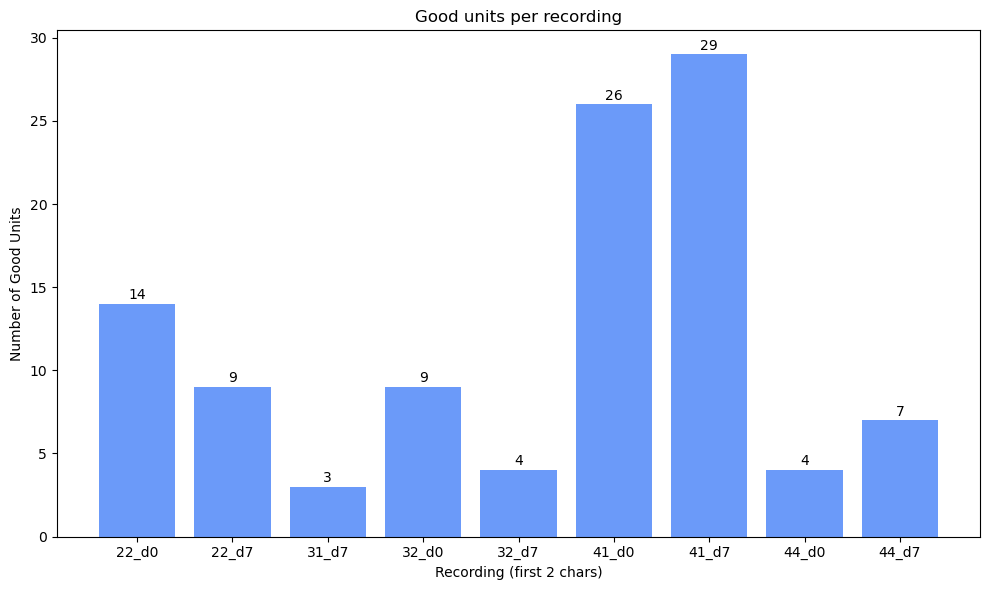

In [482]:
# plot number of good units per recording using first 2 chars of the recording name as labels
keys = list(rec_gunits.keys())
counts = list(rec_gunits.values())
labels = [str(k)[:2] + '_d' + str(k)[12:13] for k in keys]   # first two characters of each recording key

x = range(len(labels))
plt.figure(figsize=(10,6))
plt.bar(x, counts, color="#5B8FF9", alpha=0.9)
plt.xticks(x, labels)
plt.xlabel("Recording (first 2 chars)")
plt.ylabel("Number of Good Units")
plt.title("Good units per recording")
# optional: annotate counts above bars
for xi, h in zip(x, counts):
    plt.text(xi, h + 0.1, str(h), ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [493]:
# find total number of good units across all recordings
total_good_units = sum(rec_gunits.values())
print("Total good units across all recordings:", total_good_units)

Total good units across all recordings: 105


In [483]:
pivot = df_fr.pivot(index="Subject", columns="Day", values="Avg_FR")
pivot = pivot.dropna(subset=["d0", "d7"])  # keep only complete pairs
print(pivot)

# Select which pivot to analyze: 'social', 'object', or 'recording' (recording uses the original per-recording averages)
# If epoch-based pivots exist (social_pivot/object_pivot), they'll be used when selected.
analysis_mode = 'social'  # options: 'social', 'object', 'recording'
try:
    if analysis_mode == 'social':
        analysis_pivot = social_pivot
    elif analysis_mode == 'object':
        analysis_pivot = object_pivot
    elif analysis_mode == 'recording':
        analysis_pivot = pivot
    else:
        raise ValueError('unknown analysis_mode')
except NameError:
    # epoch pivots may not exist if earlier cell wasn't run; fall back to recording-level pivot
    print('epoch pivots not found; falling back to recording-level pivot')
    analysis_pivot = pivot

print(f'Using analysis_mode={analysis_mode}, N pairs={len(analysis_pivot)}')


Day            d0        d7
Subject                    
22       3.929511  3.932631
32       2.764984  2.320156
41       3.089315  3.129555
44       6.665919  3.125990
Using analysis_mode=social, N pairs=4


Social Period Wilcoxing d0 vs d7

In [484]:
social_stat, social_p = wilcoxon(social_pivot["d0"], social_pivot["d7"])
print(f"Wilcoxon signed-rank: stat={social_stat:.3f}, p={social_p:.4f}")


Wilcoxon signed-rank: stat=2.000, p=0.3750


Object Wilcoxin

In [485]:
object_stat, object_p = wilcoxon(object_pivot["d0"], object_pivot["d7"])
print(f"Wilcoxon signed-rank: stat={object_stat:.3f}, p={object_p:.4f}")


Wilcoxon signed-rank: stat=5.000, p=1.0000


Baseline Wilcoxin

In [486]:
print(baseline_pivot)

Day            d0        d7
Subject                    
22       3.901755  3.271491
32       3.109474  2.529339
41       3.190124  2.997610
44       6.986265  3.504479


In [487]:
# Compute Wilcoxon for baseline
baseline_stat, baseline_p = wilcoxon(baseline_pivot["d0"], baseline_pivot["d7"])
print(f"Baseline Wilcoxon: stat={baseline_stat:.3f}, p={baseline_p:.4f}")

Baseline Wilcoxon: stat=0.000, p=0.1250


In [488]:
social_mean_change = social_pivot["d7"].mean() - social_pivot["d0"].mean()
print(f"Mean FR change (d7 - d0): {social_mean_change:.3f} Hz")


Mean FR change (d7 - d0): -1.071 Hz


In [489]:
object_mean_change = object_pivot["d7"].mean() - object_pivot["d0"].mean()
print(f"Mean FR change (d7 - d0): {object_mean_change:.3f} Hz")

Mean FR change (d7 - d0): -0.664 Hz


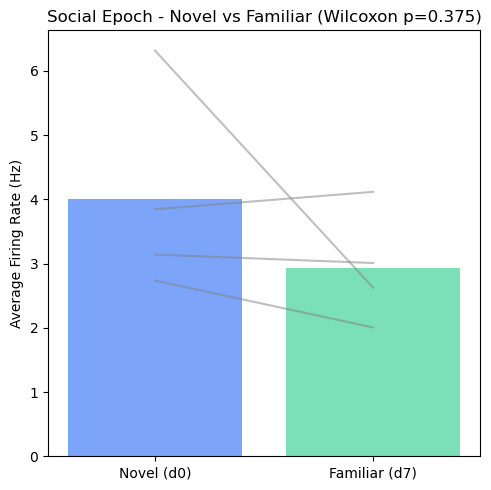

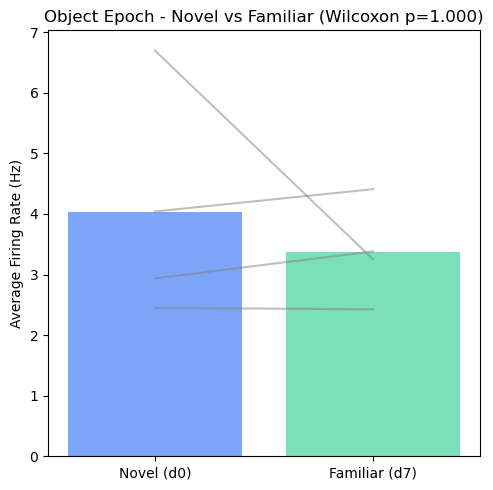

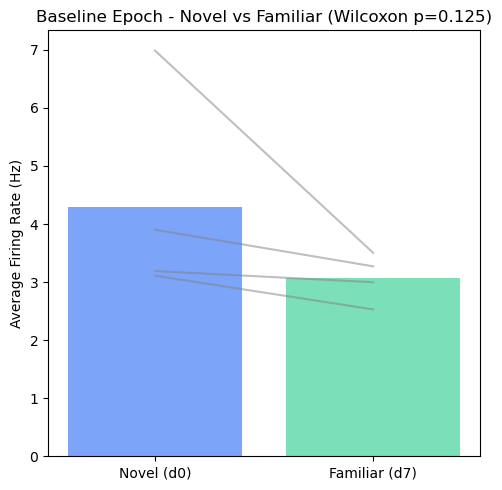

In [490]:
# Plot Social epoch
plt.figure(figsize=(5,5))
plt.bar(["Novel (d0)", "Familiar (d7)"],
        [social_pivot["d0"].mean(), social_pivot["d7"].mean()],
        color=["#5B8FF9", "#5AD8A6"], alpha=0.8)
for _, row in social_pivot.iterrows():
    plt.plot(["Novel (d0)", "Familiar (d7)"], [row["d0"], row["d7"]], color="gray", alpha=0.5)
plt.ylabel("Average Firing Rate (Hz)")
plt.title(f"Social Epoch - Novel vs Familiar (Wilcoxon p={social_p:.3f})")
plt.tight_layout()
plt.show()

# Plot Object epoch
plt.figure(figsize=(5,5))
plt.bar(["Novel (d0)", "Familiar (d7)"],
        [object_pivot["d0"].mean(), object_pivot["d7"].mean()],
        color=["#5B8FF9", "#5AD8A6"], alpha=0.8)
for _, row in object_pivot.iterrows():
    plt.plot(["Novel (d0)", "Familiar (d7)"], [row["d0"], row["d7"]], color="gray", alpha=0.5)
plt.ylabel("Average Firing Rate (Hz)")
plt.title(f"Object Epoch - Novel vs Familiar (Wilcoxon p={object_p:.3f})")
plt.tight_layout()
plt.show()

# Plot Baseline epoch
plt.figure(figsize=(5,5))
plt.bar(["Novel (d0)", "Familiar (d7)"],
        [baseline_pivot["d0"].mean(), baseline_pivot["d7"].mean()],
        color=["#5B8FF9", "#5AD8A6"], alpha=0.8)
for _, row in baseline_pivot.iterrows():
    plt.plot(["Novel (d0)", "Familiar (d7)"], [row["d0"], row["d7"]], color="gray", alpha=0.5)
plt.ylabel("Average Firing Rate (Hz)")
plt.title(f"Baseline Epoch - Novel vs Familiar (Wilcoxon p={baseline_p:.3f})")
plt.tight_layout()
plt.show()


In [491]:
# Paired permutation test (random sign-flip).
# Nonparametric, preserves pairing and often more powerful than Wilcoxon for small samples.
import numpy as np

def paired_permutation_test(x, y, n_permutations=20000, random_state=0):
    rng = np.random.default_rng(random_state)
    diffs = (y - x).dropna().values
    if len(diffs) == 0:
        return np.nan, np.nan
    obs = np.mean(diffs)
    count = 0
    for _ in range(n_permutations):
        signs = rng.choice([1, -1], size=len(diffs))
        perm_mean = np.mean(diffs * signs)
        if abs(perm_mean) >= abs(obs):
            count += 1
    p = (count + 1) / (n_permutations + 1)
    return obs, p

obs_diff, p_perm = paired_permutation_test(analysis_pivot["d0"], analysis_pivot["d7"], n_permutations=20000, random_state=0)
print(f"Permutation test (mean d7-d0) = {obs_diff:.4f} Hz, p = {p_perm:.4f}")


Permutation test (mean d7-d0) = -1.0706 Hz, p = 0.3749
